In [11]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import torch
import torchaudio

import time

import librosa
import numpy as np
from silero_vad import load_silero_vad, get_speech_timestamps

import json

import soundfile as sf
import jiwer

from demucs.api import Separator

In [3]:
device = "cuda" if torch.cuda.is_available () else "cpu"

<hr>

In [4]:
PROCESSADOR = AutoProcessor.from_pretrained (r"C:\Users\Admin\Desktop\models\ASR Models\Whisper\WhisperLv3-PT-All 4Bit")
MODELO = AutoModelForSpeechSeq2Seq.from_pretrained (r"C:\Users\Admin\Desktop\models\ASR Models\Whisper\WhisperLv3-PT-All 4Bit", device_map = device, dtype = torch.float16)

VAD = load_silero_vad ()

separator = Separator (model = "htdemucs")

W0904 13:19:51.677000 19076 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights: 100%|██████████| 1259/1259 [00:01<00:00, 849.23it/s]


In [5]:
with open (r"C:\Users\Admin\Desktop\ip\Automatic Speech Recognition\v2\Eval\audios.json", "r", encoding = "utf-8") as f:
    dataset = json.load (f)

print (dataset)

[{'audio_id': 1, 'audio_path': 'C:/Users/Admin/Desktop/ip/Automatic Speech Recognition/audio/audio1.wav', 'trans': 'Boa tarde É aí da papelaria Sim O menina dá para me guardar dois bilhetes Dois bilhetes  Sim Que bilhetes diga-me Bilhetes lá do coiso que vai acontecer na Sexta Qual é o espetáculo diga-me É lá o que acontece lá no casino que o meu neto é que quer ir Mas eu não sei qual é Você sabe  É o da Sexta sei lá o meu neto é que me pediu isto já liguei para aqui para tantos sitíos tenho que lá ir tenho que lá ir e agora disseram-me porque é que não liga lá pá papelaria que eles guardam É assim mas você para comprar tem que vir cá pagá-los Sim está bem mas tem que mos guardar não é  Não tem de vir cá para eu tirar na máquina sair da impressora o papel para você me pagar na hora não posso guardá-los Então e depois eu chego aí ', 'duration': 42}, {'audio_id': 2, 'audio_path': 'C:/Users/Admin/Desktop/ip/Automatic Speech Recognition/audio/audio2.wav', 'trans': 'Boa tarde O menina até e

In [50]:
LATENCY = []

x = []

WER = {
    "WER_CALC": []
}
CER = {
    "CER_CALC": []
}
RTF = {
    "RTF_CALC": []
}

end = 0

for exemplo in dataset:

    WAV, SR = librosa.load (exemplo["audio_path"], sr = 16000, mono = True)

    TIMESTAMPS = get_speech_timestamps (WAV, VAD)

    MODEL_TRANS = []

    for array in TIMESTAMPS:

        AUDIO = WAV [array["start"] : array ["end"]]

        torch.cuda.synchronize ()
        begin = time.time ()

        inputs = PROCESSADOR (AUDIO, sampling_rate = 16000, return_tensors = "pt", truncation = False)
        inputs = inputs["input_features"].to (device, dtype = torch.float16)

        with torch.inference_mode ():
            outputs = MODELO.generate (inputs, return_timestamps = True, task = "transcribe", language = "pt", num_beams = 5)

        torch.cuda.synchronize ()
        end = time.time () - begin
        LATENCY.append (end)

        trans = PROCESSADOR.batch_decode (outputs, skip_special_tokens = True) [0]
        trans = " ".join (str(trans).split()).lower()

        MODEL_TRANS.append (trans)

    real_trans = " ".join (str(exemplo["trans"]).split ()).lower ()
    y = " ".join (MODEL_TRANS)

    x.append (y)

    wer = jiwer.wer (real_trans, y)
    cer = jiwer.cer (real_trans, y)
    rtf = end / exemplo["duration"]

    WER[exemplo["audio_id"]] = wer
    WER["WER_CALC"].append (wer)

    CER[exemplo["audio_id"]] = cer
    CER["CER_CALC"].append (cer)

    RTF[exemplo["audio_id"]] = rtf
    RTF["RTF_CALC"].append (rtf)


In [51]:
"""
Resultados
"""

print (LATENCY)
display (x)
print (WER)
print (CER)
print (RTF) #Real Time Factor -> 

print ("---" *50)

print (f"Média da Latência: {np.mean (LATENCY)} segundos")
print (f"P50 Latência: {np.percentile (LATENCY, 50)} segundos")
print (f"P95 Latência: {np.percentile (LATENCY, 95)} segundos")

print ("---" * 50)

print (f"Média Word Error Rate: {np.mean(WER['WER_CALC'])}")
print (f"Média Character Error Rate: {np.mean(CER['CER_CALC'])}")
print (f"Média Real Time Factor: {np.mean(RTF['RTF_CALC'])}")
print (f"P50 Real Time Factor: {np.percentile(RTF['RTF_CALC'], 50)}")
print (f"P95 Real Time Factor: {np.percentile(RTF['RTF_CALC'], 95)}")

[0.8101985454559326, 1.0235800743103027, 0.31028127670288086, 1.2323729991912842, 1.4073693752288818, 0.4168977737426758, 3.959044933319092, 2.9502601623535156, 0.43291544914245605, 0.500333309173584, 1.5191659927368164, 0.5581979751586914, 0.6477468013763428, 1.657214641571045, 5.783817291259766, 0.4863853454589844, 1.610565423965454, 2.3408384323120117, 0.7923946380615234, 5.7205798625946045, 2.695800304412842, 1.1053845882415771, 2.694675922393799, 5.616448163986206, 5.93724250793457, 0.64931321144104, 1.4505910873413086, 4.083175182342529, 0.5632266998291016, 0.48108839988708496, 2.3323025703430176, 0.35645365715026855, 0.7486631870269775, 0.41772913932800293, 1.5772042274475098, 0.6832878589630127, 0.667517900466919, 1.255272626876831, 6.9459547996521, 0.6333017349243164, 0.4871499538421631, 3.911052942276001, 0.42934226989746094, 0.938126802444458, 1.628382682800293, 4.46688985824585, 0.29746508598327637, 1.9555115699768066, 0.6171114444732666, 0.9291868209838867, 1.4949033260345

['é a da papelaria ó menina dá para me guardar dois bilhetes sim bilhete de lá do do coiso que vai acontecer na sexta é logo o que acontece lá no casino que o meu neto é que quer ir você sabe eu às seis dei sei lá o meu neto é que me pediu já liguei para aqui para aquele sítio tenho que ir lá ir tenho que ir lá ir e agora me disseram porque é que não liga lá para a papelaria que eles guardam mas você para comprar tem que vir cá para losnão tenho que vir cá para eu tirar na máquina sair da impressora o papel para você me pagar na hora eu não posso guardar los',
 'e boa tarde homem nem a que é toda nervosa que vem do lado de baixo ó menina eu já a encontrei controla o quê encontrei a elisa então eu vou passar aqui às relações públicas e está bem geralmente relações públicas boa tarde olha menina eu já encontrei a elisa que ela mora aqui em baixo vocês todas as noites perguntam uma vizinha minha já me tinha dito que ela mora ali em baixo temos que ligar para ela para avisar e agora o meu 

{'WER_CALC': [0.39215686274509803, 0.35135135135135137, 0.1694915254237288, 0.44607843137254904, 0.4230769230769231, 0.2727272727272727, 0.47058823529411764, 0.40487804878048783, 0.44680851063829785, 3.642857142857143, 0.3875, 0.32432432432432434, 0.38323353293413176, 0.4377880184331797], 1: 0.39215686274509803, 2: 0.35135135135135137, 3: 0.1694915254237288, 4: 0.44607843137254904, 5: 0.4230769230769231, 6: 0.2727272727272727, 7: 0.47058823529411764, 8: 0.40487804878048783, 9: 0.44680851063829785, 10: 3.642857142857143, 11: 0.3875, 12: 0.32432432432432434, 13: 0.38323353293413176, 14: 0.4377880184331797}
{'CER_CALC': [0.31622746185852985, 0.17486338797814208, 0.09878682842287695, 0.3246231155778894, 0.32863187588152326, 0.25167336010709507, 0.42828282828282827, 0.30275229357798167, 0.33642691415313225, 3.439814814814815, 0.28760529482551145, 0.20861486486486486, 0.29949238578680204, 0.37344028520499106], 1: 0.31622746185852985, 2: 0.17486338797814208, 3: 0.09878682842287695, 4: 0.32462

<hr>

In [7]:
import noisereduce as nr
import librosa
import soundfile as sf
import torch

WAV, SR = librosa.load (r"C:\Users\Admin\Desktop\audio files\2_background noise.wav", sr = 16000, mono = False)

WAV = torch.from_numpy (WAV)


WAV_noise_reduce = nr.reduce_noise (WAV, sr = SR, stationary = True)
WAV_peak_normal = WAV / torch.max (torch.abs (WAV)) 

sf.write ("y.wav", WAV_noise_reduce, samplerate = 16000)
sf.write ("z.wav", WAV_peak_normal, samplerate = 16000)



<hr>

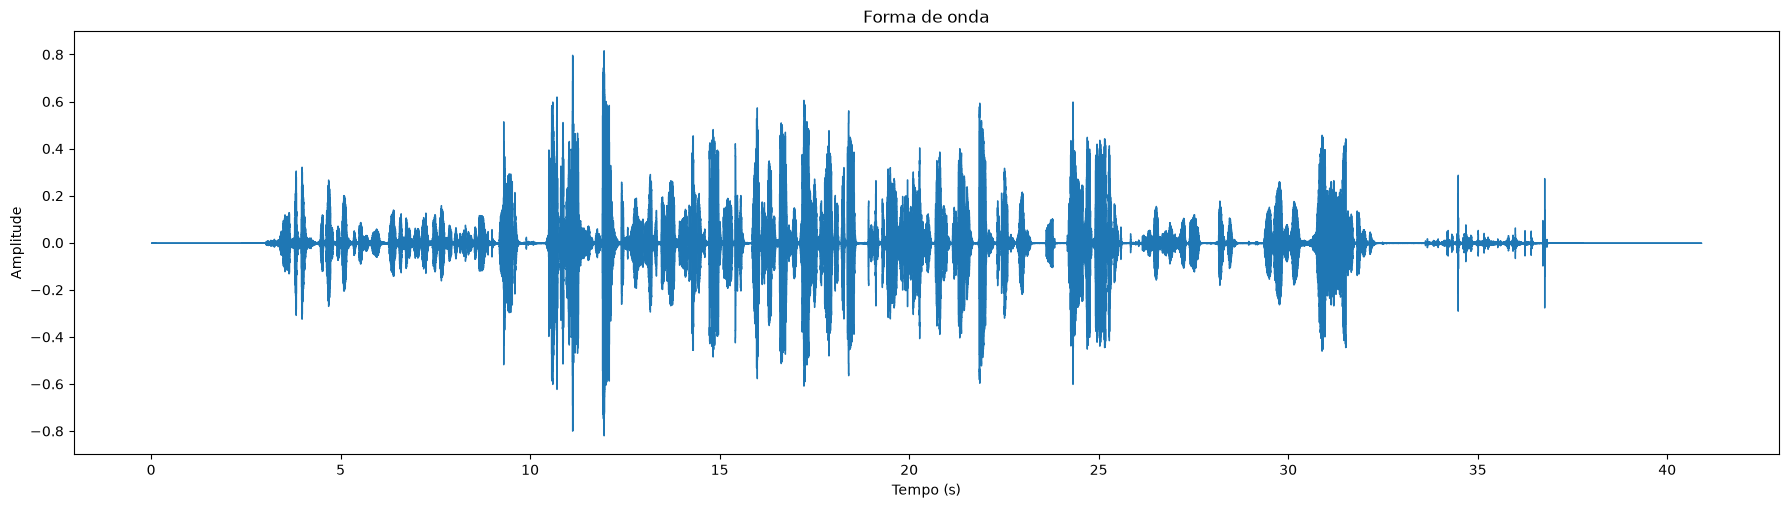

In [16]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

WAV, SR = librosa.load (r"C:\Users\Admin\Desktop\audio files\2_background noise.wav", sr = 16000, mono = True)

plt.figure (figsize = (22 , 5.5))
librosa.display.waveshow(WAV, sr=SR)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Forma de onda")
plt.show()


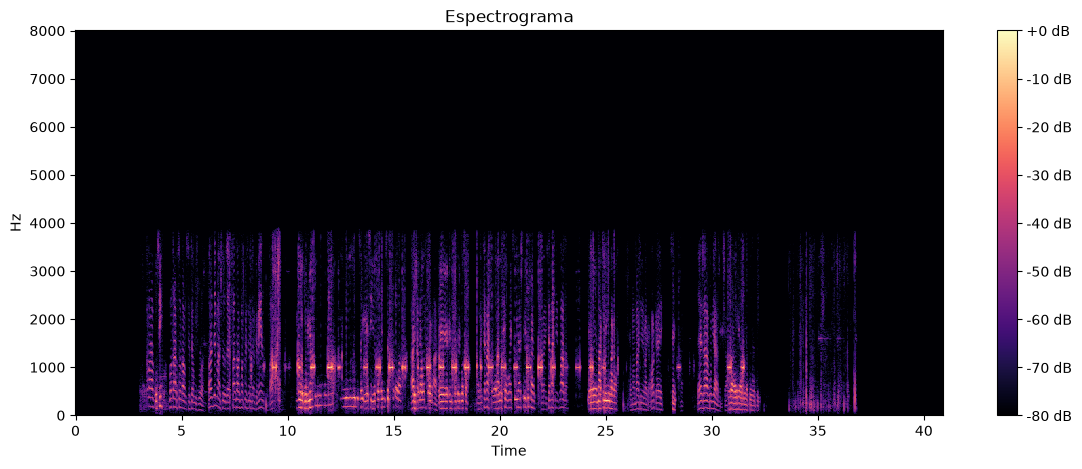

In [20]:
import numpy as np


D = librosa.stft(WAV)
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    S_db,
    sr=SR,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma")
plt.show()

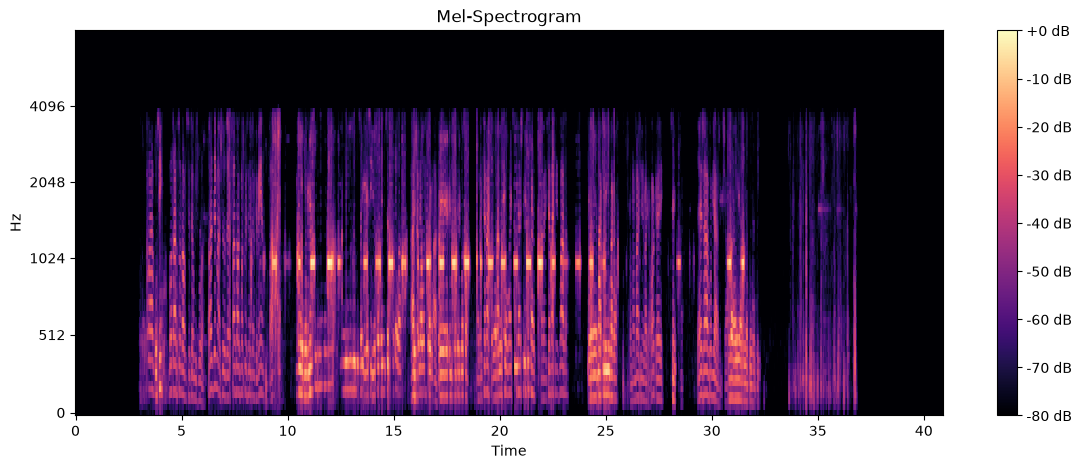

In [21]:
M = librosa.feature.melspectrogram(
    y=WAV,
    sr=SR,
    n_mels=80
)

M_db = librosa.power_to_db(M, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(
    M_db,
    sr=SR,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram")
plt.show()